# Task

1. Create “HW5.ipynb” – this will be the file for your homework.
2. In this homework you will analyze the Kaggle Heart Failure Dataset.
3. Your task is to explore this dataset. Here is an example of what you can do:

a. check the features and explanations of their meaning (for that you can check
Data Card on Kaggle and google the topic a little bit to gain some
understanding of the problem and related features),

b. check features effect on target variable (heart failure),

c. check for missing data and outliers.

d. bivariate/multivariate data analysis,

e. suggest for possible feature engineering or variable encoding,

f. provide some conclusions in the end about the dataset.

4. Format your IPYNB notebook as a comprehensive report, as you would do for a
person who is not familiar with the data – you need to present your results clearly and tell a story about what data is inside.
5. Create “HW5” branch in your repo.
6. Upload your IPYNB file into “HW5” and create a pull request to submit your work.

In [2]:
from google.colab import drive
import pandas as pd
import numpy as np
import seaborn as sns
from matplotlib import pyplot as plt
from sklearn import datasets, decomposition

In [3]:
drive.mount('/content/drive')
data = pd.read_csv('/content/drive/My Drive/ScientificPython/heart.csv')

data.head()

Mounted at /content/drive


,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             918 non-null    int64  
 1   Sex             918 non-null    object 
 2   ChestPainType   918 non-null    object 
 3   RestingBP       918 non-null    int64  
 4   Cholesterol     918 non-null    int64  
 5   FastingBS       918 non-null    int64  
 6   RestingECG      918 non-null    object 
 7   MaxHR           918 non-null    int64  
 8   ExerciseAngina  918 non-null    object 
 9   Oldpeak         918 non-null    float64
 10  ST_Slope        918 non-null    object 
 11  HeartDisease    918 non-null    int64  
dtypes: float64(1), int64(6), object(5)
memory usage: 86.2+ KB


In [5]:
len(data)

918

In [6]:
# checking for total null values
data.isnull().sum()

,0
Age,0
Sex,0
ChestPainType,0
RestingBP,0
Cholesterol,0
FastingBS,0
RestingECG,0
MaxHR,0
ExerciseAngina,0
Oldpeak,0


Thus, there's no NaN.

# Data anomalies check

In [7]:
print(f"Patients with zero blood pressure: {(data['RestingBP'] == 0).sum()}")
print(f"Patients with zero cholesterol: {(data['Cholesterol'] == 0).sum()}")
print(f"Patients with zero max heart rate: {(data['MaxHR'] == 0).sum()}")
print(f"Patients with zero age: {(data['Age'] == 0).sum()}")

Patients with zero blood pressure: 1
Patients with zero cholesterol: 172
Patients with zero max heart rate: 0
Patients with zero age: 0


Patients with zero blood pressure: 1 \
Patients with zero cholesterol: 172 - ~18-19% of the dataset. \
Patients with zero max heart rate: 0 - correct. \
Patients with zero age: 0 - correct.

# Observations
172 patients (almost 19% of the dataset) have cholesterol recorded as 0, which is medically impossible. This likely represents missing data or measurement errors. **This requires attention** before any predictive modeling.


Total patients: 918
Patients with zero cholesterol: 172
Patients with valid cholesterol: 746


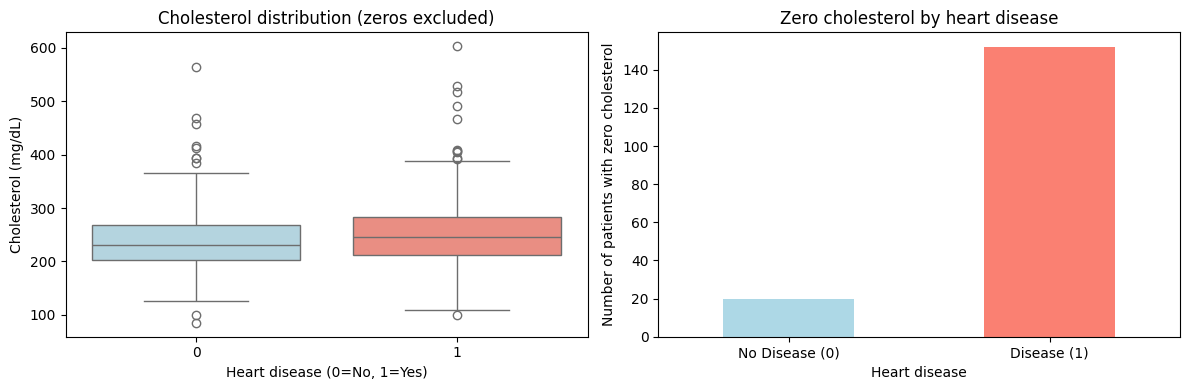

Percentage of zeros among healthy (HeartDisease=0): 4.9%
Percentage of zeros among diseased (HeartDisease=1): 29.9%


In [8]:
# Cholesterol analysis excluding zeros
print(f"Total patients: {len(data)}")
print(f"Patients with zero cholesterol: {(data['Cholesterol'] == 0).sum()}")
print(f"Patients with valid cholesterol: {(data['Cholesterol'] > 0).sum()}")

# Create clean dataset for cholesterol visualization
cholesterol_valid = data[data['Cholesterol'] > 0]

# Plot comparison
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Fixed boxplot (removed palette, using color instead)
sns.boxplot(data=cholesterol_valid, x='HeartDisease', y='Cholesterol',
            ax=axes[0], hue='HeartDisease', palette=['lightblue', 'salmon'], legend=False)
axes[0].set_title('Cholesterol distribution (zeros excluded)')
axes[0].set_xlabel('Heart disease (0=No, 1=Yes)')
axes[0].set_ylabel('Cholesterol (mg/dL)')

# Bar plot showing proportion of zeros by Heart Disease
zero_by_disease = data.groupby('HeartDisease')['Cholesterol'].apply(lambda x: (x == 0).sum())
zero_by_disease.plot.bar(ax=axes[1], color=['lightblue', 'salmon'])
axes[1].set_title('Zero cholesterol by heart disease')
axes[1].set_xlabel('Heart disease')
axes[1].set_ylabel('Number of patients with zero cholesterol')
axes[1].set_xticklabels(['No Disease (0)', 'Disease (1)'], rotation=0)

plt.tight_layout()
plt.show()

# What percentage of zeros in each class?
# Zero cholesterol by class
zero_pct_by_disease = data.groupby('HeartDisease')['Cholesterol'].apply(lambda x: (x == 0).sum() / len(x) * 100)
print(f"Percentage of zeros among healthy (HeartDisease=0): {zero_pct_by_disease[0]:.1f}%")
print(f"Percentage of zeros among diseased (HeartDisease=1): {zero_pct_by_disease[1]:.1f}%")

Patients with heart disease are **6 times more likely** to have missing cholesterol data (29.9% vs 4.9%). This is **not random** - it's a systematic bias in the dataset.

What can we do?

1. Treat "Cholesterol = 0" as a separate category ("unknown") rather than removing.
2. Use multiple imputation techniques that account for non-random missingness.
3. Remove zeros only if you understand why they occur.

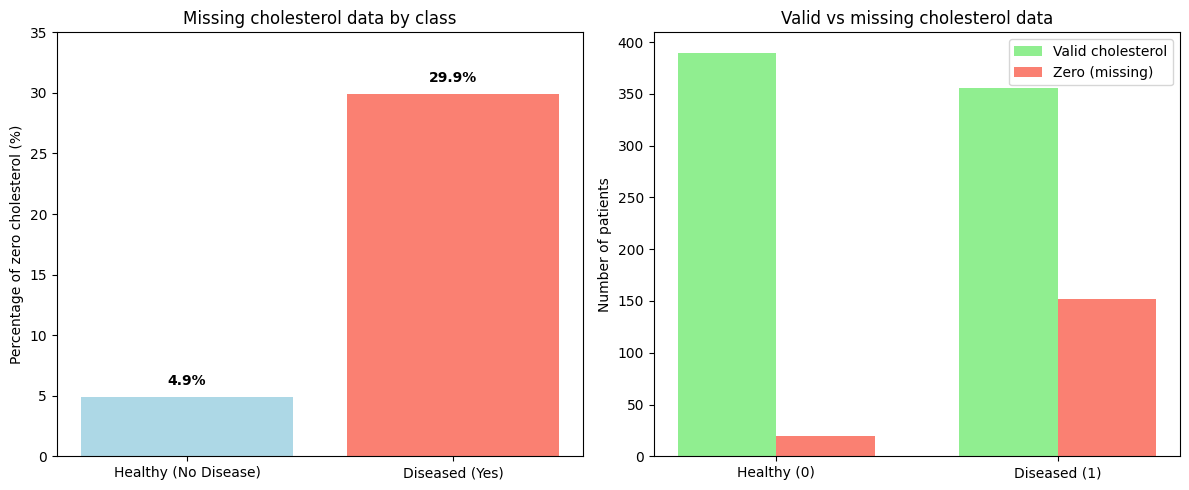

Healthy patients missing: 4.9%
Diseased patients missing: 29.9%
Difference: 25 percentage points (6x more likely to be missing in diseased group)

 This indicates !non-random! missing data - a systematic bias.


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Bar chart of zero percentages
zero_percentages = [4.9, 29.9]
bars = axes[0].bar(['Healthy (No Disease)', 'Diseased (Yes)'], zero_percentages,
                    color=['lightblue', 'salmon'])
axes[0].set_ylabel('Percentage of zero cholesterol (%)')
axes[0].set_title('Missing cholesterol data by class')
axes[0].set_ylim(0, 35)

# Add value labels on bars
for bar, value in zip(bars, zero_percentages):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                f'{value}%', ha='center', fontweight='bold')

# Count of zeros vs non-zeros by class
zero_counts = data.groupby('HeartDisease')['Cholesterol'].apply(lambda x: (x == 0).sum())
non_zero_counts = data.groupby('HeartDisease')['Cholesterol'].apply(lambda x: (x > 0).sum())

x = ['Healthy (0)', 'Diseased (1)']
width = 0.35
axes[1].bar([i - width/2 for i in range(len(x))], non_zero_counts, width,
            label='Valid cholesterol', color='lightgreen')
axes[1].bar([i + width/2 for i in range(len(x))], zero_counts, width,
            label='Zero (missing)', color='salmon')
axes[1].set_ylabel('Number of patients')
axes[1].set_title('Valid vs missing cholesterol data')
axes[1].set_xticks(range(len(x)))
axes[1].set_xticklabels(x)
axes[1].legend()

plt.tight_layout()
plt.show()

print(f"Healthy patients missing: 4.9%")
print(f"Diseased patients missing: 29.9%")
print(f"Difference: 25 percentage points (6x more likely to be missing in diseased group)")
print("\n This indicates !non-random! missing data - a systematic bias.")

/tmp/ipykernel_13650/3037504891.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data, x='HeartDisease', ax=ax[1], palette='Set2')


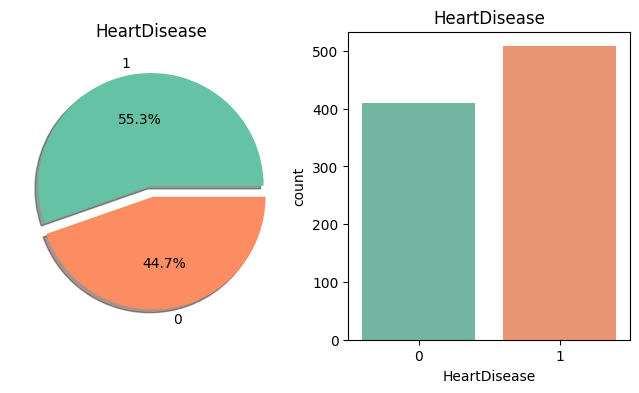

In [10]:
# Check how many have disease

# Create subplots
f, ax = plt.subplots(1, 2, figsize=(8, 4))

# Piechart for the first subplot
data['HeartDisease'].value_counts().plot.pie(explode=[0,0.1],autopct='%1.1f%%',ax=ax[0],shadow=True, colors=sns.color_palette('Set2'))
ax[0].set_title('HeartDisease')
ax[0].set_ylabel('')

# Countplot for the second subplot
sns.countplot(data, x='HeartDisease', ax=ax[1], palette='Set2')
ax[1].set_title('HeartDisease')

plt.show()

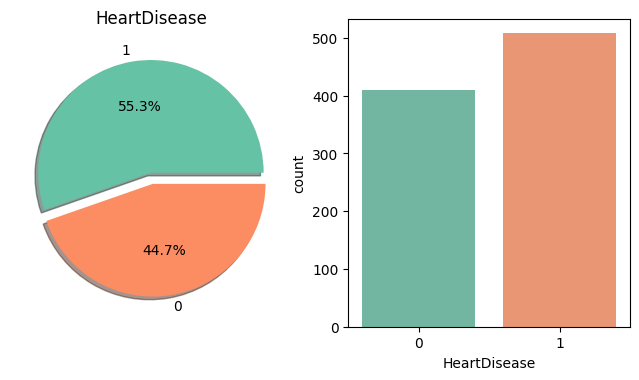

In [11]:
# Check how many have disease

# Create subplots
f, ax = plt.subplots(1, 2, figsize=(8, 4))

# Piechart for the first subplot
data['HeartDisease'].value_counts().plot.pie(explode=[0,0.1],autopct='%1.1f%%',ax=ax[0],shadow=True, colors=sns.color_palette('Set2'))
ax[0].set_title('HeartDisease')
ax[0].set_ylabel('')

# Countplot for the second subplot
sns.countplot(data, x='HeartDisease', hue='HeartDisease', ax=ax[1], palette='Set2', legend=False)

plt.show()

In [12]:
# This will give us the exact number
print(data['HeartDisease'].value_counts())

HeartDisease
1    508
0    410
Name: count, dtype: int64


# Observations

It's evident that more than half of the patients have heart disease.

Out of 918 patients in the dataset, 508 patients have heart disease i.e 55.3% of the total dataset have heart disease, while 44.7% are healthy. We need to dig down more to get better insights from the data and see which categories of patients are more likely to have heart disease and who is not.

We will try to check the heart disease rate by using the different features of the dataset. Some of the features being Sex, Chest Pain Type, Age, Exercise Angina, etc.

# Feature types

1. **Categorical Features:**
A categorical variable is one that has two or more categories and each value in that feature can be categorised by them. For example, gender is a categorical variable having two categories (male and female). Now we cannot sort or give any ordering to such variables. They are also known as Nominal Variables. **Categorical Features in the dataset: Sex, ChestPainType, FastingBS, RestingECG, ExerciseAngina.** \
1.1. ***Binary Features** (a binary feature has only two possible values):*
***Sex (M/F), FastingBS (0/1), ExerciseAngina (N/Y), HeartDisease (0/1 - target variable).***

2. **Ordinal Features:**
An ordinal variable is similar to categorical values, but the difference between them is that we can have relative ordering or sorting between the values. For eg: If we have a feature like Height with values Tall, Medium, Short, then Height is a ordinal variable. Here we can have a relative sort in the variable. **Ordinal Features in the dataset: ST_Slope.**

3. **Continous Feature:**
A feature is said to be continous if it can take values between any two points or between the minimum or maximum values in the features column. **Continous Features in the dataset: Age, RestingBP, Cholesterol, MaxHR, Oldpeak**

## Cheatsheet
1. **Age** = 	Age in years (=> **continous**)

2. **Sex** = male or female (=> binary **categorical**)

3. **ChestPainType** = Type of chest pain (ATA, NAP, ASY, TA) (=> **categorical**)

4. **RestingBP** = Blood pressure at rest (=> **continous**)

5. **Cholesterol** = Cholesterol level in blood (=> **continous**)

6. **FastingBS** = High blood sugar (1/0) (=> binary **categorical**)

7. **RestingECG** = ECG results at rest (Normal, ST, LVH) (=> **categorical**)

8. **MaxHR** = Maximum heart rate achieved (=> **continous**)

9. **ExerciseAngina** = Chest pain during exercise (Y/N) (=> binary **categorical**)

10. **Oldpeak** = ST depression value (=> **continous**)

11. **ST_Slope** = Slope of ST segment (Up, Flat, Down), Up ~ good, Down ~ bad (=> **ordinal**)

12. **HeartDisease** = 0/1, **target** and binary **categorical**

# Sex -> binary categorical feature

In [13]:
pd.crosstab(data.Sex, data.HeartDisease, margins=True).style.background_gradient(cmap='summer_r')

HeartDisease,0,1,All
Sex,,,
F,143,50,193
M,267,458,725
All,410,508,918


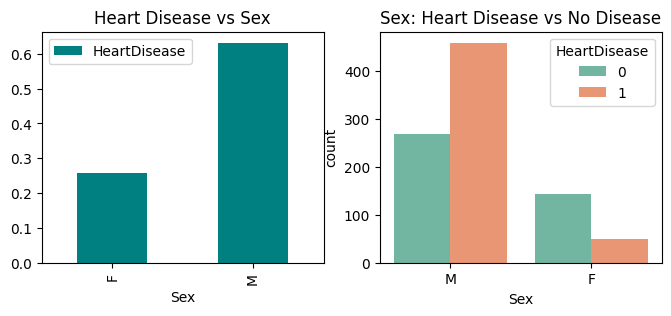

In [14]:
f, ax=plt.subplots(1, 2, figsize=(8,3))

data[['Sex','HeartDisease']].groupby(['Sex']).mean().plot.bar(ax=ax[0], color='teal')
ax[0].set_title('Heart Disease vs Sex')

sns.countplot(data, x='Sex',hue='HeartDisease', ax=ax[1], palette='Set2')
ax[1].set_title('Sex: Heart Disease vs No Disease')

plt.show()

In [15]:
# Calculate heart disease rate by sex
data.groupby('Sex')['HeartDisease'].mean()

,HeartDisease
Sex,
F,0.259067
M,0.631724


# Observations

The number of male patients in the dataset is higher than the number of female patients. Still the number of females with heart disease is lower compared to males.
The heart disease rate for females is around 25% while that for males is around 63%.

# FastingBS -> binary categorical feature

In [16]:
pd.crosstab(data.FastingBS, data.HeartDisease, margins=True).style.background_gradient(cmap='summer_r')

HeartDisease,0,1,All
FastingBS,,,
0,366,338,704
1,44,170,214
All,410,508,918


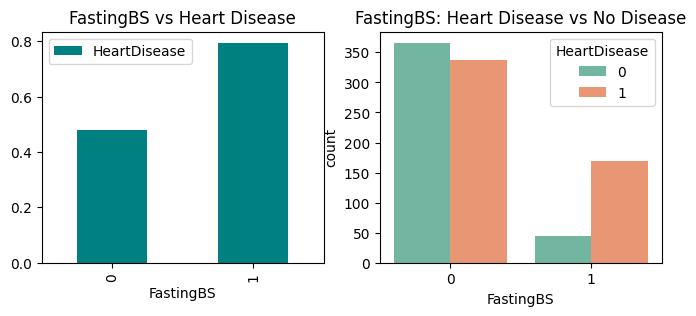

In [27]:
f, ax=plt.subplots(1, 2, figsize=(8,3))

data[['FastingBS','HeartDisease']].groupby(['FastingBS']).mean().plot.bar(ax=ax[0], color='teal')
ax[0].set_title('FastingBS vs Heart Disease')

sns.countplot(data, x='FastingBS',hue='HeartDisease', ax=ax[1], palette='Set2')
ax[1].set_title('FastingBS: Heart Disease vs No Disease')

plt.show()

# Observations

Patients with high fasting blood sugar (FastingBS = 1) have a significantly higher risk of heart disease (79% vs. 48%). This is expected, as diabetes is a known risk factor.


# ExerciseAngina -> binary categorical feature

In [30]:
pd.crosstab(data.ExerciseAngina, data.HeartDisease, margins=True).style.background_gradient(cmap='summer_r')

HeartDisease,0,1,All
ExerciseAngina,,,
N,355,192,547
Y,55,316,371
All,410,508,918


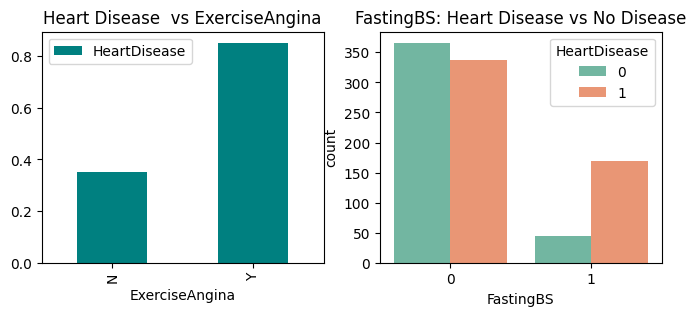

In [31]:
f, ax=plt.subplots(1, 2, figsize=(8,3))

data[['ExerciseAngina','HeartDisease']].groupby(['ExerciseAngina']).mean().plot.bar(ax=ax[0], color='teal')
ax[0].set_title('Heart Disease  vs ExerciseAngina')

sns.countplot(data, x='FastingBS',hue='HeartDisease', ax=ax[1], palette='Set2')
ax[1].set_title('FastingBS: Heart Disease vs No Disease')

plt.show()

# Observations

Patients with ExerciseAngina = Y (chest pain during exercise) have a heart disease rate of 316 out of 371 (85%).

Patients with ExerciseAngina = N have a heart disease rate of only 192 out of 547 (35%).

Quite a huge difference. ExerciseAngina is one of the strongest predictors of heart disease in this dataset.

# RestingECG -> categorical feature

In [33]:
pd.crosstab(data.RestingECG, data.HeartDisease, margins=True).style.background_gradient(cmap='summer_r')

HeartDisease,0,1,All
RestingECG,,,
LVH,82,106,188
Normal,267,285,552
ST,61,117,178
All,410,508,918


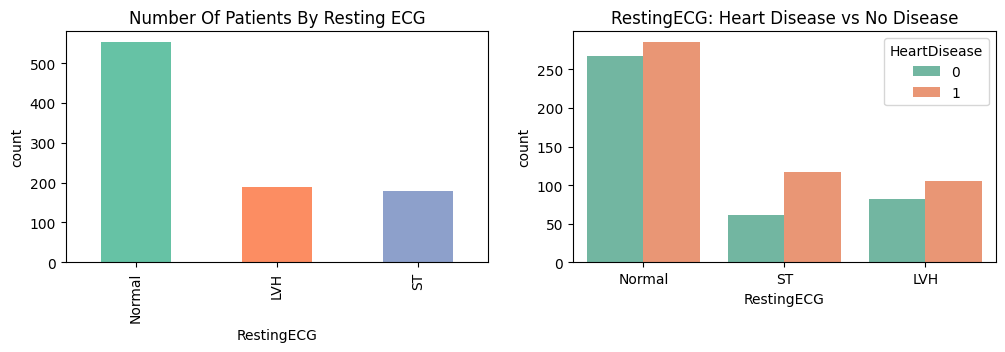

In [32]:
pd.crosstab(data.RestingECG, data.HeartDisease, margins=True).style.background_gradient(cmap='summer_r')

f, ax = plt.subplots(1, 2, figsize=(12,3))

data['RestingECG'].value_counts().plot.bar(color=sns.color_palette('Set2'), ax=ax[0])
ax[0].set_title('Number Of Patients By Resting ECG')
ax[0].set_ylabel('count')

sns.countplot(data, x='RestingECG', hue='HeartDisease', ax=ax[1], palette='Set2')
ax[1].set_title('RestingECG: Heart Disease vs No Disease')

plt.show()

# Observations

Patients with ST abnormality have the highest heart disease rate: 117 out of 178 patients, which is around 66%.

Patients with LVH (Left Ventricular Hypertrophy) have a heart disease rate of 106 out of 188, around 56%.

Patients with Normal RestingECG have the lowest heart disease rate: 285 out of 552, around 52%.

The difference between categories is not as dramatic as with ChestPainType or ST_Slope. Normal ECG still shows 52% disease rate, which is only slightly lower than LVH (56%) and ST (66%).

This suggests that RestingECG is a weaker predictor compared to other features like ChestPainType or ST_Slope.

However, patients with ST abnormality still show the highest risk and may be useful for modeling.

# ChestPainType -> categorical feature
In theory, ChestPainType is more like a categorical feature, because the values don’t have a natural order. ATA, NAP, ASY, TA are just names for different types of pain. You can’t say that ATA is "greater than" or "less than" NAP. There’s no "severity level" or "rank" column in the table. Each type of pain is simply a category.


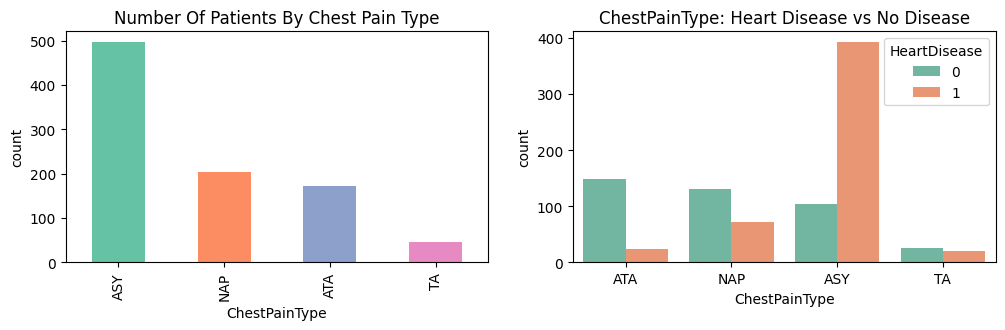

In [17]:
# ChestPainType -> categorical feature

pd.crosstab(data.ChestPainType, data.HeartDisease, margins=True).style.background_gradient(cmap='summer_r')

f, ax = plt.subplots(1, 2, figsize=(12,3))

data['ChestPainType'].value_counts().plot.bar(color=sns.color_palette('Set2'), ax=ax[0])
ax[0].set_title('Number Of Patients By Chest Pain Type')
ax[0].set_ylabel('count')

sns.countplot(data, x='ChestPainType', hue='HeartDisease', ax=ax[1], palette='Set2')
ax[1].set_title('ChestPainType: Heart Disease vs No Disease')

plt.show()

# Observations

Looking at the bar plot, we can clearly see that the most common chest pain type among patients is ASY (Atypical), followed by NAP, ATA, and TA being the least common.
For the second plot, we can see that patients with ASY chest pain have a significantly higher number of heart disease cases (value 1), with the count reaching almost 400. In contrast, patients with other chest pain types (ATA, NAP, TA) have a much lower number of heart disease cases.
This suggests that ASY chest pain is strongly associated with heart disease.

Returning to the definition of ChestPainType as a categorical or ordinal feature - from a medical standpoint, different types of chest pain do have different correlations with heart disease. But that’s already a result of analysis, not a property of the data. You discover that DURING the analysis, not specify it in advance.

*Cheatsheet* \
ASY = Atypical angina (high risk level) \
NAP = Non-anginal pain (medium risk level) \
ATA = Typical angina (medium risk level) \
TA = Asymptomatic (low risk level)

# Age -> continuous feature

In [35]:
print('Oldest Patient was of:',data['Age'].max(),'Years')
print('Youngest Patient was of:',data['Age'].min(),'Years')
print('Average Age on the dataset:',data['Age'].mean(),'Years')

Oldest Patient was of: 77 Years
Youngest Patient was of: 28 Years
Average Age on the dataset: 53.510893246187365 Years


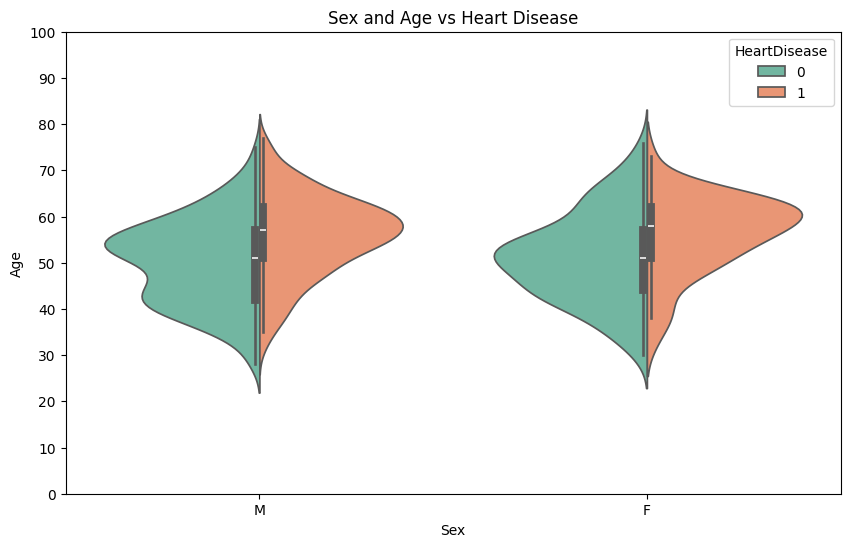

In [38]:
plt.figure(figsize=(10,6))
sns.violinplot(data, x="Sex", y="Age", hue="HeartDisease", split=True, palette="Set2")
plt.title('Sex and Age vs Heart Disease')
plt.yticks(range(0, 110, 10))
plt.show()

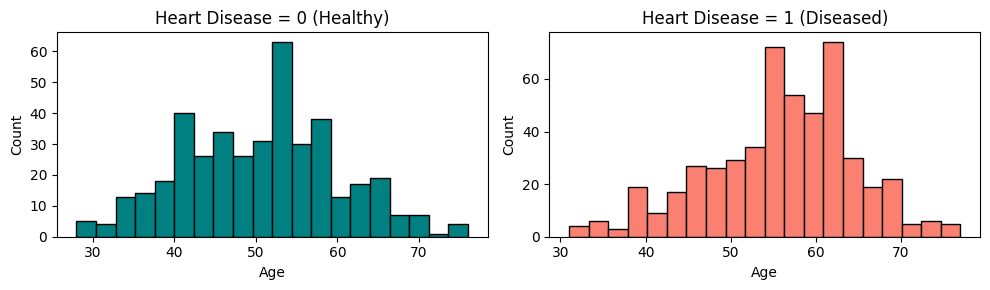

In [41]:
# Age distribution for Healthy vs Diseased
f, ax = plt.subplots(1,2,figsize=(10,3))

data[data['HeartDisease']==0].Age.plot.hist(ax=ax[0], bins=20, edgecolor='black', color='teal')
ax[0].set_title('Heart Disease = 0 (Healthy)')
ax[0].set_xlabel('Age')
ax[0].set_ylabel('Count')

data[data['HeartDisease']==1].Age.plot.hist(ax=ax[1], bins=20, edgecolor='black', color='salmon')
ax[1].set_title('Heart Disease = 1 (Diseased)')
ax[1].set_xlabel('Age')
ax[1].set_ylabel('Count')

plt.tight_layout()
plt.show()

# Observations

The age range in the dataset is from 28 to 77 years, with an average age of 53.5 years.

Obviously, older age is associated with higher risk of heart disease regardless of sex.

Let's move on to the analysis of ordinal features.

# ST_Slope -> ordinal feature

In [18]:
# ST_Slope -> ordinal feature

pd.crosstab(data.ST_Slope, data.HeartDisease, margins=True).style.background_gradient(cmap='summer_r')

HeartDisease,0,1,All
ST_Slope,,,
Down,14,49,63
Flat,79,381,460
Up,317,78,395
All,410,508,918


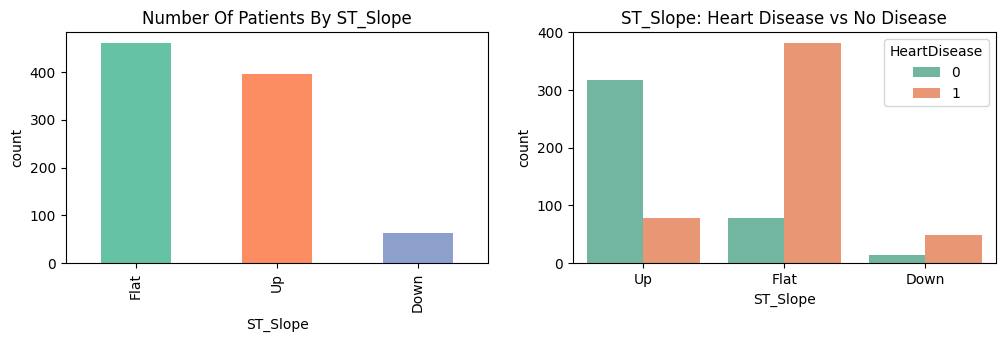

In [19]:
f, ax = plt.subplots(1, 2, figsize=(12,3))

data['ST_Slope'].value_counts().plot.bar(color=sns.color_palette('Set2'), ax=ax[0])
ax[0].set_title('Number Of Patients By ST_Slope')
ax[0].set_ylabel('count')

sns.countplot(data, x='ST_Slope', hue='HeartDisease', ax=ax[1], palette='Set2')
ax[1].set_title('ST_Slope: Heart Disease vs No Disease')

plt.show()

In [20]:
pd.crosstab([data.Sex, data.HeartDisease], data.ST_Slope, margins=True).style.background_gradient(cmap='summer_r')

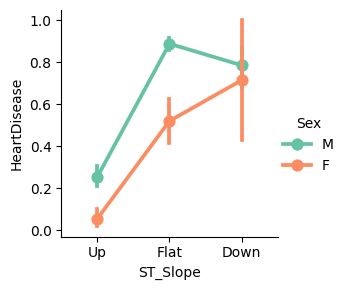

In [21]:
sns.catplot(data, x='ST_Slope', y='HeartDisease', hue='Sex', palette='Set2',
            kind="point", height=3, aspect=1)

# Observations

We can clearly see that patients with Up ST_Slope have a much lower rate of heart disease compared to those with Flat or Down ST_Slope. Even though the number of patients with Flat ST_Slope is the highest (460 patients), the number of heart disease cases among them is very high, somewhere around 83% (381 out of 460).

For patients with Up ST_Slope, the heart disease rate is only around 20% (78 out of 395).

For patients with Down ST_Slope, the heart disease rate is around 78% (49 out of 63).

Let's dive in little bit more and check for other interesting observations. Let's check heart disease rate with Sex and ST_Slope together.

We use CatPlot in this case, because it makes the separation of categorical values easy.

Looking at the CrossTab and the CatPlot, we can easily infer that heart disease for females with Up ST_Slope is very low — only 6 out of 111 females with Up ST_Slope have heart disease (about 5%). However, for females with Flat ST_Slope, the rate jumps to 39 out of 75 (about 52%).

For males, the pattern is even more striking. Males with Up ST_Slope have a heart disease rate of 72 out of 284 (about 25%), while males with Flat ST_Slope have a rate of 342 out of 385 (about 89%). Males with Down ST_Slope have a rate of 44 out of 56 (about 79%).

It's evident that regardless of sex, Flat and Down ST_Slope are strong indicators of heart disease, while Up ST_Slope appears to be protective.

### Correlations (heatmap)

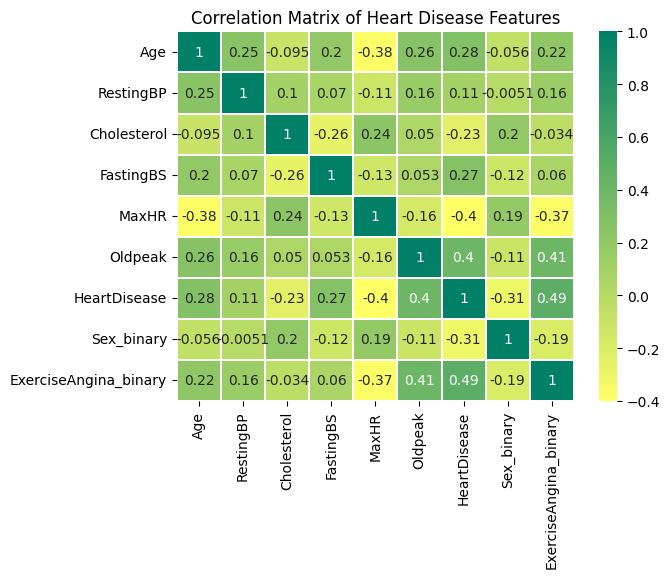

In [45]:
# Create correlation dataframe
data = data.drop(['Initial'], axis=1)
data_corr = data.drop(['ChestPainType', 'RestingECG', 'ST_Slope'], axis=1)

# Convert binary categorical to numeric for correlation
data_corr['Sex_binary'] = data['Sex'].map({'M': 0, 'F': 1})
data_corr['ExerciseAngina_binary'] = data['ExerciseAngina'].map({'N': 0, 'Y': 1})

# Drop the original string columns (they are still in data_corr because we didn't drop them initially)
data_corr = data_corr.drop(['Sex', 'ExerciseAngina'], axis=1)

# Plot heatmap
sns.heatmap(data_corr.corr(), annot=True, cmap='summer_r', linewidths=0.2)
plt.title('Correlation Matrix of Heart Disease Features')
plt.show()

In [46]:
data_corr = data.drop(['ChestPainType', 'RestingECG', 'ST_Slope'], axis=1)

data_corr['Sex_binary'] = data['Sex'].map({'M': 0, 'F': 1})
data_corr['ExerciseAngina_binary'] = data['ExerciseAngina'].map({'N': 0, 'Y': 1})
data_corr = data_corr.drop(['Sex', 'ExerciseAngina'], axis=1)
corr_matrix = data_corr.corr()
corr_matrix

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease,Sex_binary,ExerciseAngina_binary
Age,1.000000,0.254399,-0.095282,0.198039,-0.382045,0.258612,0.282039,-0.055750,0.215793
RestingBP,0.254399,1.000000,0.100893,0.070193,-0.112135,0.164803,0.107589,-0.005133,0.155101
Cholesterol,-0.095282,0.100893,1.000000,-0.260974,0.235792,0.050148,-0.232741,0.200092,-0.034166
FastingBS,0.198039,0.070193,-0.260974,1.000000,-0.131438,0.052698,0.267291,-0.120076,0.060451
MaxHR,-0.382045,-0.112135,0.235792,-0.131438,1.000000,-0.160691,-0.400421,0.189186,-0.370425
Oldpeak,0.258612,0.164803,0.050148,0.052698,-0.160691,1.000000,0.403951,-0.105734,0.408752
HeartDisease,0.282039,0.107589,-0.232741,0.267291,-0.400421,0.403951,1.000000,-0.305445,0.494282
Sex_binary,-0.055750,-0.005133,0.200092,-0.120076,0.189186,-0.105734,-0.305445,1.000000,-0.190664
ExerciseAngina_binary,0.215793,0.155101,-0.034166,0.060451,-0.370425,0.408752,0.494282,-0.190664,1.000000


The first thing to note is that only the numeric features are compared as it is obvious that we cannot correlate between alphabets or strings.

- ExerciseAngina (0.49) and Oldpeak (0.40) are the strongest predictors.

- MaxHR (-0.40) is a strong inverse predictor (low heart rate = high risk).

- No two features correlate too strongly (maximum ~0.41).

All features can be used for model building - there is no multicollinearity.

## Feature engineering and Data cleaning

Whenever we are given a dataset with features, **it is not necessary that all the features will be important**. There maybe be many redundant features which should be eliminated. Also we can get or add new features by observing or extracting information from other features.

### Age band

Problem With Age Feature:

Age is a continous feature, there is a certain problem with continous variables in Machine Learning models.

Eg: We can group or arrange Person by gender, but how to group them by their Age? If there are 30 persons, there may be 30 age values. Now this is problematic.

We need to **convert these continous values into categorical values**. We can using **binning** i.e group a range of ages into a single bin or assign them a single value.

In [47]:
data['Age_band']=0
data.loc[data['Age']<=16,'Age_band']=0
data.loc[(data['Age']>16)&(data['Age']<=32),'Age_band']=1
data.loc[(data['Age']>32)&(data['Age']<=48),'Age_band']=2
data.loc[(data['Age']>48)&(data['Age']<=64),'Age_band']=3
data.loc[data['Age']>64,'Age_band']=4
data.head(2)

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease,Age_band
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0,2
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1,3


In [48]:
data['Age_band'].value_counts().to_frame().style.background_gradient(cmap='summer')

,count
Age_band,
3,545
2,258
4,103
1,12


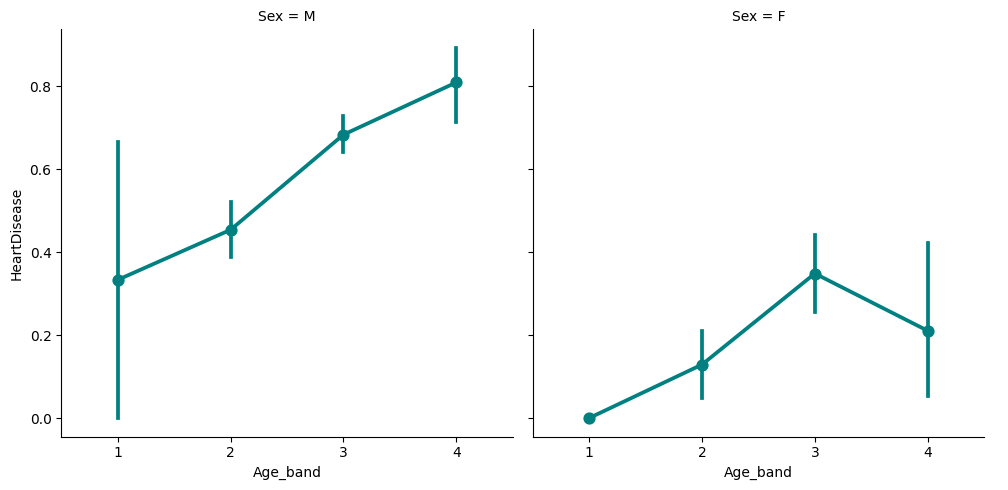

In [49]:
sns.catplot(data, x='Age_band', y='HeartDisease', col='Sex', kind='point', color='teal')

# Observations

We divided the age range into 4 bands (0-16, 17-32, 33-48, 49-64, 65+).

Most patients fall into Age band 3 (49-64 years) with 545 patients, followed by Age band 2 (33-48 years) with 258 patients. Very few patients are in the youngest age band (17-32 years) — only 12 patients.

This suggests that the dataset primarily contains middle-aged and older patients, which makes sense given that heart disease is more common in older populations.

### Continuous features that can be transformed

Let's choose MaxHR, since it is strongly correlated with the target variable (-0.40).


In [50]:
# MaxHR Range
# Since MaxHR is also a continuous feature, we need to convert it into ordinal value using pandas.qcut.
# Pandas qcut splits or arranges the values according the number of bins we have passed. So if we pass for 4 bins, it will arrange the values equally spaced into 4 separate bins or value ranges.

data['MaxHR_Range'] = pd.qcut(data['MaxHR'], 4)
data.groupby(['MaxHR_Range'])['HeartDisease'].mean().to_frame().style.background_gradient(cmap='summer_r')

/tmp/ipykernel_13650/2720558460.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  data.groupby(['MaxHR_Range'])['HeartDisease'].mean().to_frame().style.background_gradient(cmap='summer_r')


,HeartDisease
MaxHR_Range,
"(59.999, 120.0]",0.773946
"(120.0, 138.0]",0.647059
"(138.0, 156.0]",0.500000
"(156.0, 202.0]",0.262443


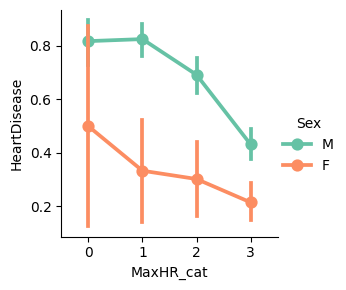

In [51]:
# As discussed above, we can clearly see that as the MaxHR_Range decreases, the chances of heart disease increases.
# Now we cannot pass the MaxHR_Range values as it is. We should convert it into singleton values same as we did in age_band

data['MaxHR_cat'] = 0
data.loc[data['MaxHR'] <= 100, 'MaxHR_cat'] = 0
data.loc[(data['MaxHR'] > 100) & (data['MaxHR'] <= 120), 'MaxHR_cat'] = 1
data.loc[(data['MaxHR'] > 120) & (data['MaxHR'] <= 140), 'MaxHR_cat'] = 2
data.loc[(data['MaxHR'] > 140) & (data['MaxHR'] <= 202), 'MaxHR_cat'] = 3

sns.catplot(data, x='MaxHR_cat', y='HeartDisease', hue='Sex', kind='point', palette='Set2', height=3)

# Clearly, as the MaxHR_cat increases, the heart disease rate decreases.
# This feature may become an important feature during modeling along with Sex.

# Observations

Patients with maximum heart rate below 120 have a 77.4% heart disease rate, while patients with maximum heart rate above 156 have only a 26.2% heart disease rate.

This shows a clear inverse relationship: **lower MaxHR = higher risk of heart disease**.

### Dropping Features

Age --> we have Age_band feature, so no need of this

MaxHR --> we have MaxHR_cat feature, so unneeded

MaxHR_Range --> we have MaxHR_cat feature

In [52]:
data.drop(['Age', 'MaxHR', 'MaxHR_Range'], axis=1, inplace=True)

In [53]:
print(data.columns)

Index(['Sex', 'ChestPainType', 'RestingBP', 'Cholesterol', 'FastingBS',
       'RestingECG', 'ExerciseAngina', 'Oldpeak', 'ST_Slope', 'HeartDisease',
       'Age_band', 'MaxHR_cat'],
      dtype='object')


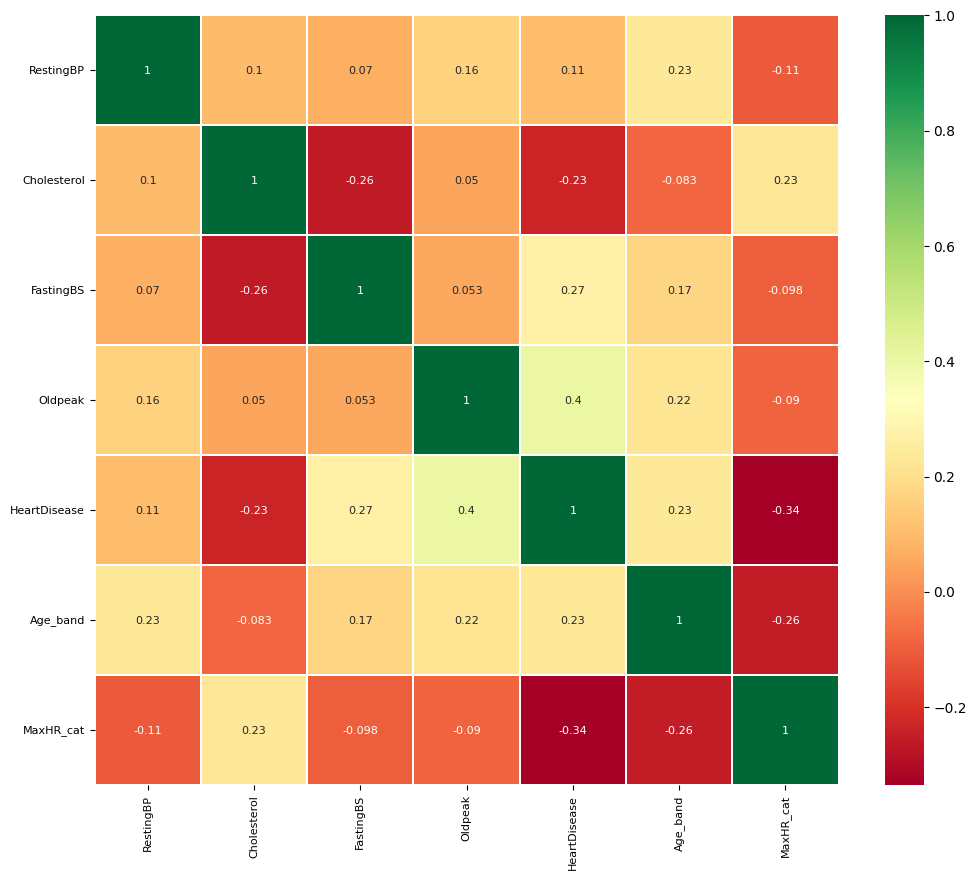

In [55]:
# Drop string columns before correlation
data_for_corr = data.drop(['Sex', 'ChestPainType', 'RestingECG', 'ExerciseAngina', 'ST_Slope'], axis=1)

sns.heatmap(data_for_corr.corr(), annot=True, cmap='RdYlGn', linewidths=0.2, annot_kws={'size':8})
fig=plt.gcf()
fig.set_size_inches(12,10)
plt.xticks(fontsize=8)
plt.yticks(fontsize=8)
plt.show()

In [56]:
data_for_corr = data.drop(['Sex', 'ChestPainType', 'RestingECG', 'ExerciseAngina', 'ST_Slope'], axis=1)
corr_matrix = data_for_corr.corr()
corr_matrix

,RestingBP,Cholesterol,FastingBS,Oldpeak,HeartDisease,Age_band,MaxHR_cat
RestingBP,1.000000,0.100893,0.070193,0.164803,0.107589,0.234141,-0.107067
Cholesterol,0.100893,1.000000,-0.260974,0.050148,-0.232741,-0.082725,0.232105
FastingBS,0.070193,-0.260974,1.000000,0.052698,0.267291,0.172443,-0.097864
Oldpeak,0.164803,0.050148,0.052698,1.000000,0.403951,0.220650,-0.090272
HeartDisease,0.107589,-0.232741,0.267291,0.403951,1.000000,0.233594,-0.335679
Age_band,0.234141,-0.082725,0.172443,0.220650,0.233594,1.000000,-0.256465
MaxHR_cat,-0.107067,0.232105,-0.097864,-0.090272,-0.335679,-0.256465,1.000000


### Observations

For the final correlation matrix I would use the first matrix (with Age, MaxHR, Sex_binary, ExerciseAngina_binary). It shows more accurate relationships.
**The new matrix is less informative** because **the strong predictors** (ExerciseAngina_binary at 0.49) **have been lost**, and **binarization has reduced the correlation of key features**.